AI-POWERED DRIVING EFFICIENCY OPTIMIZER

Sample Dataset:
   Speed  Terrain  Braking  Energy_Consumption
0     71       11       17           38.921956
1    112        9       18           47.381264
2     34        2       18           26.713706
3     91        4        4           25.938817
4     80        5       17           37.950096

Model Performance
------------------------------
Mean Absolute Error : 2.42
R² Score            : 0.91

Enter Driving Parameters
Speed (km/h): 150
Terrain Level (0-15): 2
Braking Frequency (0-20): 4


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(



Predicted Energy Consumption:
33.04 units

Driving Efficiency Tips
------------------------------
• Reduce speed to improve battery efficiency.

Efficiency Score: 66.96 /100


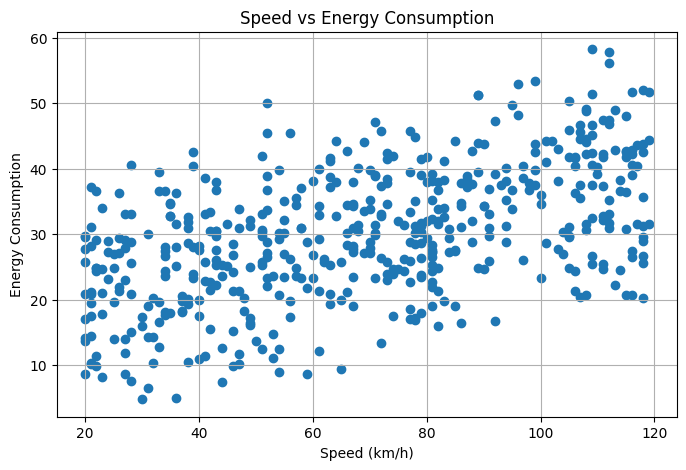

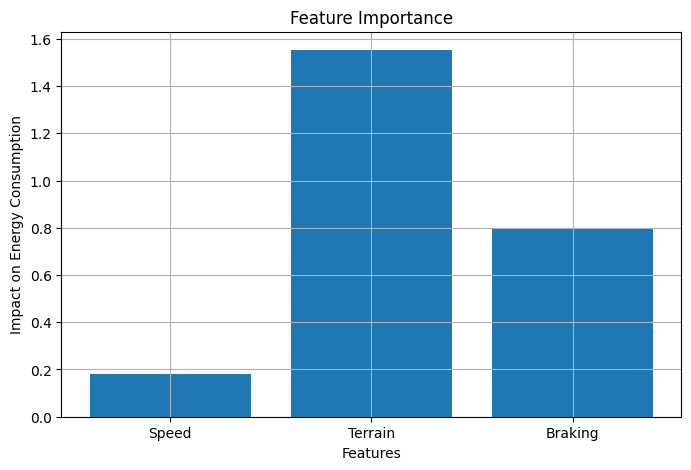


Project Completed Successfully!


In [1]:
# ==========================================
# AI-Powered Driving Efficiency Optimizer
# EV Internship Project
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("="*60)
print("AI-POWERED DRIVING EFFICIENCY OPTIMIZER")
print("="*60)

# -------------------------------------------------
# STEP 1: Generate Simulated EV Driving Dataset
# -------------------------------------------------

np.random.seed(42)

n = 500

speed = np.random.randint(20, 120, n)          # km/h
terrain = np.random.randint(0, 15, n)          # terrain difficulty
braking = np.random.randint(0, 20, n)          # braking frequency

energy = (
    speed * 0.18 +
    terrain * 1.5 +
    braking * 0.8 +
    np.random.normal(0, 3, n)
)

df = pd.DataFrame({
    "Speed": speed,
    "Terrain": terrain,
    "Braking": braking,
    "Energy_Consumption": energy
})

print("\nSample Dataset:")
print(df.head())

# -------------------------------------------------
# STEP 2: Train Machine Learning Model
# -------------------------------------------------

X = df[["Speed", "Terrain", "Braking"]]
y = df["Energy_Consumption"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\nModel Performance")
print("-"*30)
print("Mean Absolute Error :", round(mae, 2))
print("R² Score            :", round(r2, 2))

# -------------------------------------------------
# STEP 3: User Input
# -------------------------------------------------

print("\nEnter Driving Parameters")

speed_input = float(input("Speed (km/h): "))
terrain_input = float(input("Terrain Level (0-15): "))
braking_input = float(input("Braking Frequency (0-20): "))

prediction = model.predict(
    [[speed_input, terrain_input, braking_input]]
)

predicted_energy = prediction[0]

print("\nPredicted Energy Consumption:")
print(round(predicted_energy, 2), "units")

# -------------------------------------------------
# STEP 4: Driving Efficiency Analysis
# -------------------------------------------------

print("\nDriving Efficiency Tips")
print("-"*30)

tips = []

if speed_input > 90:
    tips.append("Reduce speed to improve battery efficiency.")

if braking_input > 10:
    tips.append("Avoid frequent braking and maintain steady driving.")

if terrain_input > 10:
    tips.append("Steep terrain increases energy consumption.")

if predicted_energy < 25:
    tips.append("Excellent driving efficiency.")

if len(tips) == 0:
    tips.append("Good driving behavior detected.")

for tip in tips:
    print("•", tip)

# -------------------------------------------------
# STEP 5: Efficiency Score
# -------------------------------------------------

efficiency_score = max(
    0,
    100 - predicted_energy
)

print("\nEfficiency Score:", round(efficiency_score, 2), "/100")

# -------------------------------------------------
# STEP 6: Visualization
# -------------------------------------------------

plt.figure(figsize=(8,5))
plt.scatter(df["Speed"], df["Energy_Consumption"])
plt.xlabel("Speed (km/h)")
plt.ylabel("Energy Consumption")
plt.title("Speed vs Energy Consumption")
plt.grid(True)
plt.show()

# -------------------------------------------------
# STEP 7: Feature Importance
# -------------------------------------------------

features = ["Speed", "Terrain", "Braking"]

plt.figure(figsize=(8,5))
plt.bar(features, np.abs(model.coef_))
plt.xlabel("Features")
plt.ylabel("Impact on Energy Consumption")
plt.title("Feature Importance")
plt.grid(True)
plt.show()

print("\nProject Completed Successfully!")